
Dataset size = 1000
MinHash build : 22.864 ± 2.593 ms
MinHash query : 450.132 ± 53.287 ms
MinHash P@10  : 1.0000
MinHash err   : 0.000539
MinHash mem   : 2.384 MB
LSH build     : 43.905 ± 12.515 ms
LSH query     : 2.357 ± 0.361 ms
LSH P@10      : 0.0220
LSH err       : 0.001818
LSH avg cand  : 0.20
LSH mem       : 3.535 MB

Dataset size = 10000
MinHash build : 217.936 ± 20.169 ms
MinHash query : 2221.673 ± 177.500 ms
MinHash P@10  : 0.8554
MinHash err   : 0.020352
MinHash mem   : 11.384 MB
LSH build     : 346.791 ± 60.475 ms
LSH query     : 2.406 ± 0.396 ms
LSH P@10      : 0.0069
LSH err       : 0.000875
LSH avg cand  : 0.13
LSH mem       : 16.982 MB


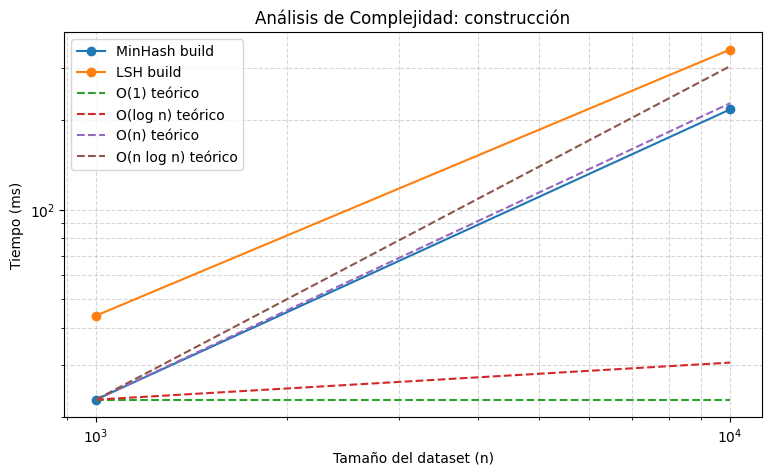

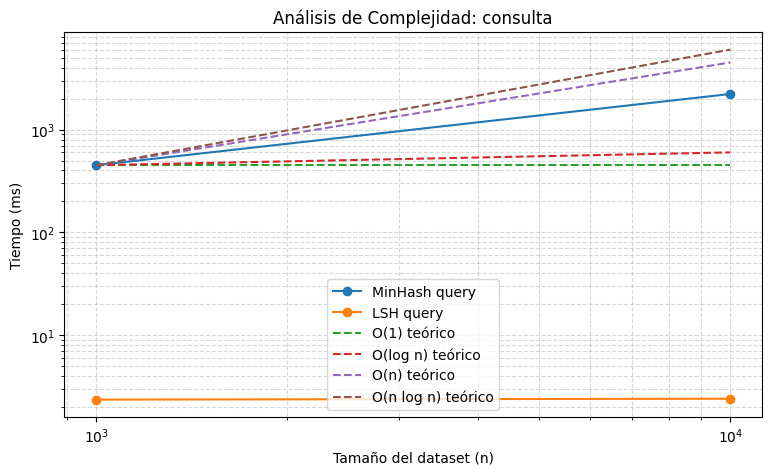

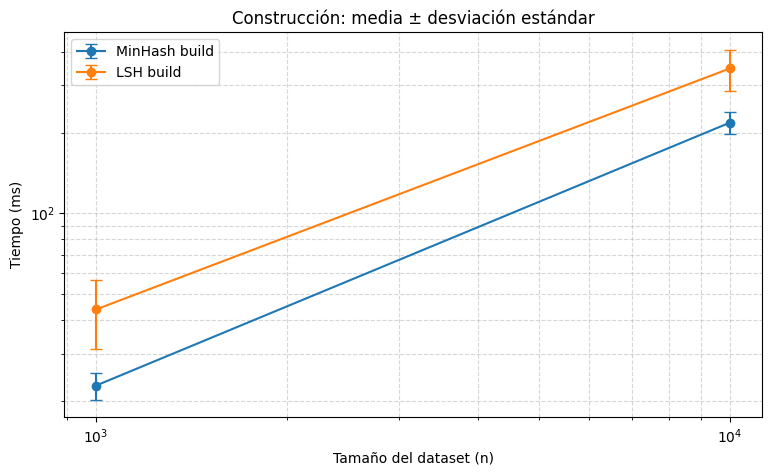

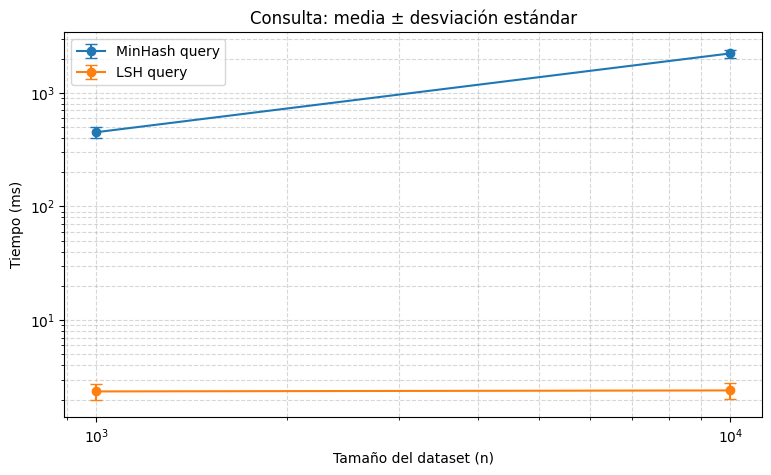

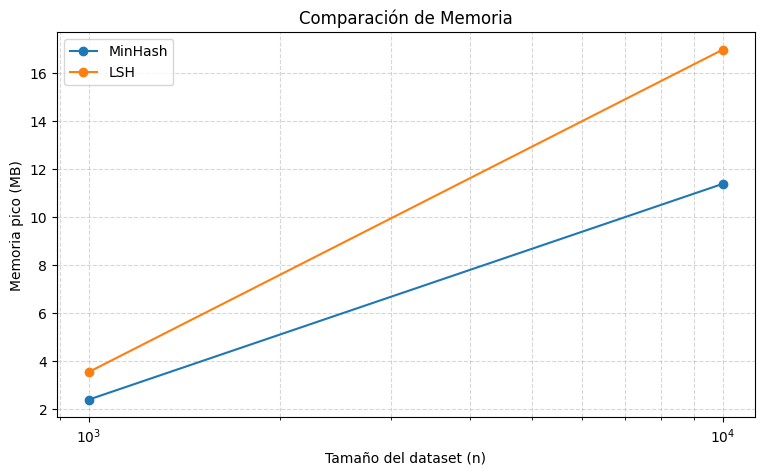

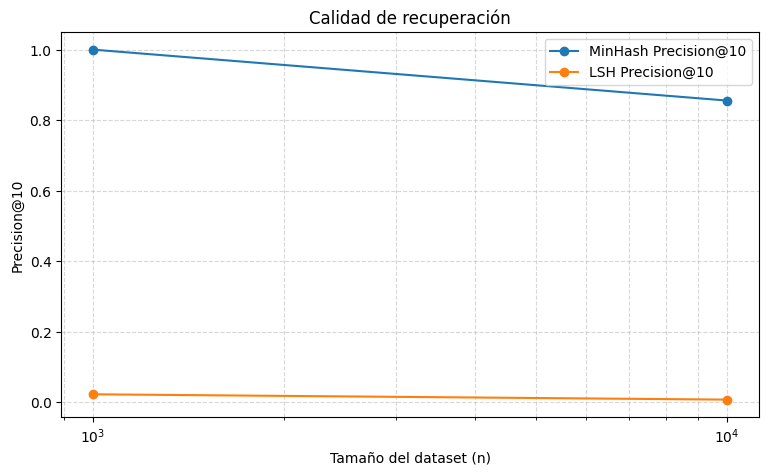

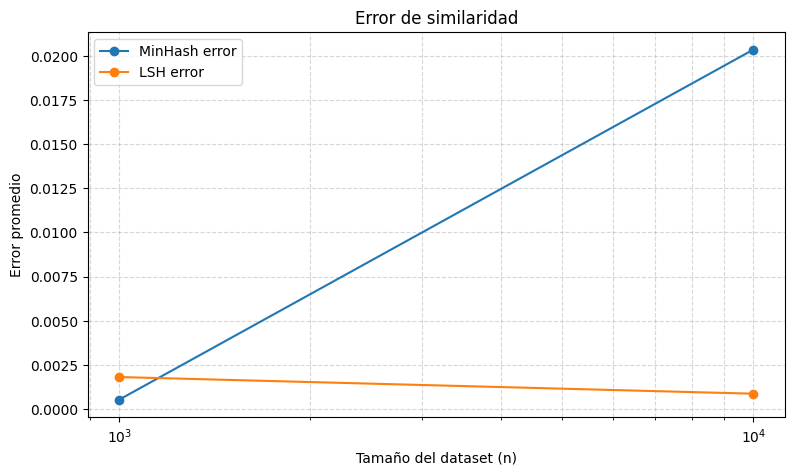

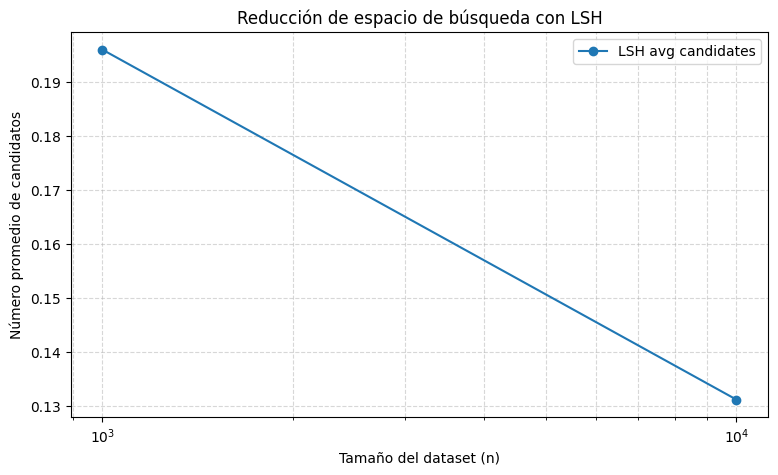


         n |     MH build |     MH query |    MH P@10 |       MH err |       MH Mem |    LSH build |    LSH query |   LSH P@10 |      LSH err |      LSH Mem
      1000 |       22.864 |      450.132 |     1.0000 |     0.000539 |        2.384 |       43.905 |        2.357 |     0.0220 |     0.001818 |        3.535
     10000 |      217.936 |     2221.673 |     0.8554 |     0.020352 |       11.384 |      346.791 |        2.406 |     0.0069 |     0.000875 |       16.982


In [2]:
# =========================================================
# EXPERIMENTACIÓN Y ANÁLISIS
# Sistema de Recomendación
# Comparación: MinHash vs LSH
# =========================================================

import random
import time
import math
import statistics
import tracemalloc
import hashlib
import heapq
import matplotlib.pyplot as plt


# =========================================================
# 1. GENERADOR DE DATASET
# =========================================================
# Genera usuarios con patrones de co-watching:
# cada usuario ve un subconjunto de videos.
# Habrá grupos latentes para crear similitud real.

def generate_user_video_dataset(
    n_events,
    num_users=5000,
    num_videos=10000,
    num_clusters=20,
    seed=42
):
    random.seed(seed)

    users = [f"user_{i}" for i in range(num_users)]
    videos = [f"video_{i}" for i in range(num_videos)]

    # centroides de gustos por cluster
    cluster_profiles = []
    for _ in range(num_clusters):
        cluster_profiles.append(set(random.sample(videos, min(200, num_videos))))

    user_cluster = {}
    user_sets = {u: set() for u in users}

    for u in users:
        c = random.randint(0, num_clusters - 1)
        user_cluster[u] = c

    # repartir eventos user-video
    for _ in range(n_events):
        u = random.choice(users)
        c = user_cluster[u]

        if random.random() < 0.8:
            v = random.choice(list(cluster_profiles[c]))
        else:
            v = random.choice(videos)

        user_sets[u].add(v)

    # limpiar usuarios vacíos
    user_sets = {u: s for u, s in user_sets.items() if len(s) > 0}

    return user_sets


# =========================================================
# 2. JACCARD EXACTO
# =========================================================
def jaccard_similarity(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0


# =========================================================
# 3. MINHASH
# =========================================================
class MinHash:
    def __init__(self, num_hashes=64, max_shingle_id=10**7):
        self.num_hashes = num_hashes
        self.max_shingle_id = max_shingle_id
        self.prime = 4294967311
        random.seed(12345)
        self.hash_params = [
            (random.randint(1, self.prime - 1), random.randint(0, self.prime - 1))
            for _ in range(num_hashes)
        ]

    def _to_int(self, token):
        return int(hashlib.blake2b(token.encode(), digest_size=8).hexdigest(), 16)

    def signature(self, token_set):
        sig = [float("inf")] * self.num_hashes

        for token in token_set:
            x = self._to_int(token)
            for i, (a, b) in enumerate(self.hash_params):
                h = (a * x + b) % self.prime
                if h < sig[i]:
                    sig[i] = h

        return sig

    def similarity(self, sig_a, sig_b):
        eq = sum(1 for a, b in zip(sig_a, sig_b) if a == b)
        return eq / self.num_hashes


# =========================================================
# 4. LSH SOBRE FIRMAS MINHASH
# =========================================================
class LSHIndex:
    def __init__(self, bands=8, rows=8):
        self.bands = bands
        self.rows = rows
        self.buckets = [{} for _ in range(bands)]

    def _band_hash(self, band_slice):
        band_str = "|".join(map(str, band_slice))
        return hashlib.blake2b(band_str.encode(), digest_size=8).hexdigest()

    def insert(self, item_id, signature):
        for b in range(self.bands):
            start = b * self.rows
            end = start + self.rows
            band_slice = signature[start:end]
            key = self._band_hash(band_slice)

            if key not in self.buckets[b]:
                self.buckets[b][key] = []
            self.buckets[b][key].append(item_id)

    def query_candidates(self, signature):
        candidates = set()
        for b in range(self.bands):
            start = b * self.rows
            end = start + self.rows
            band_slice = signature[start:end]
            key = self._band_hash(band_slice)

            if key in self.buckets[b]:
                for item_id in self.buckets[b][key]:
                    candidates.add(item_id)
        return candidates


# =========================================================
# 5. TOP-K USUARIOS SIMILARES
# =========================================================
def top_k_exact(query_user, user_sets, k=10):
    qset = user_sets[query_user]
    scores = []

    for u, s in user_sets.items():
        if u == query_user:
            continue
        sim = jaccard_similarity(qset, s)
        scores.append((sim, u))

    return heapq.nlargest(k, scores)


def top_k_minhash(query_user, user_sets, signatures, minhash, k=10):
    qsig = signatures[query_user]
    scores = []

    for u, sig in signatures.items():
        if u == query_user:
            continue
        sim = minhash.similarity(qsig, sig)
        scores.append((sim, u))

    return heapq.nlargest(k, scores)


def top_k_lsh(query_user, user_sets, signatures, minhash, lsh, k=10):
    qsig = signatures[query_user]
    candidates = lsh.query_candidates(qsig)

    if query_user in candidates:
        candidates.remove(query_user)

    scores = []
    for u in candidates:
        sim = minhash.similarity(qsig, signatures[u])
        scores.append((sim, u))

    return heapq.nlargest(k, scores), len(candidates)


# =========================================================
# 6. BENCHMARKS
# =========================================================
def benchmark_minhash(user_sets, num_hashes=64, query_count=200, k=10):
    mh = MinHash(num_hashes=num_hashes)

    # build signatures
    t0 = time.perf_counter()
    signatures = {u: mh.signature(videos) for u, videos in user_sets.items()}
    t1 = time.perf_counter()
    build_ms = (t1 - t0) * 1000

    users = list(user_sets.keys())
    query_users = random.sample(users, min(query_count, len(users)))

    # query top-k
    t0 = time.perf_counter()
    results = {}
    for q in query_users:
        results[q] = top_k_minhash(q, user_sets, signatures, mh, k=k)
    t1 = time.perf_counter()
    query_ms = (t1 - t0) * 1000

    return mh, signatures, build_ms, query_ms, results, query_users


def benchmark_lsh(user_sets, num_hashes=64, bands=8, rows=8, query_count=200, k=10):
    mh = MinHash(num_hashes=num_hashes)

    # build signatures
    t0 = time.perf_counter()
    signatures = {u: mh.signature(videos) for u, videos in user_sets.items()}
    lsh = LSHIndex(bands=bands, rows=rows)
    for u, sig in signatures.items():
        lsh.insert(u, sig)
    t1 = time.perf_counter()
    build_ms = (t1 - t0) * 1000

    users = list(user_sets.keys())
    query_users = random.sample(users, min(query_count, len(users)))

    # query top-k
    t0 = time.perf_counter()
    results = {}
    candidate_sizes = []
    for q in query_users:
        topk, cand_size = top_k_lsh(q, user_sets, signatures, mh, lsh, k=k)
        results[q] = topk
        candidate_sizes.append(cand_size)
    t1 = time.perf_counter()
    query_ms = (t1 - t0) * 1000

    avg_candidates = sum(candidate_sizes) / len(candidate_sizes) if candidate_sizes else 0

    return mh, signatures, lsh, build_ms, query_ms, results, query_users, avg_candidates


# =========================================================
# 7. MÉTRICAS DE CALIDAD
# =========================================================
def precision_at_k(approx_results, exact_results, k=10):
    precisions = []

    for q in exact_results:
        exact_ids = [u for _, u in exact_results[q][:k]]
        approx_ids = [u for _, u in approx_results.get(q, [])[:k]]

        if len(approx_ids) == 0:
            precisions.append(0.0)
            continue

        hits = len(set(exact_ids) & set(approx_ids))
        precisions.append(hits / k)

    return sum(precisions) / len(precisions) if precisions else 0.0


def avg_similarity_error(approx_results, exact_results, k=10):
    errors = []

    for q in exact_results:
        exact_scores = {u: sim for sim, u in exact_results[q][:k]}
        approx_scores = {u: sim for sim, u in approx_results.get(q, [])[:k]}

        common_users = set(exact_scores.keys()) & set(approx_scores.keys())
        for u in common_users:
            errors.append(abs(approx_scores[u] - exact_scores[u]))

    return sum(errors) / len(errors) if errors else 0.0


# =========================================================
# 8. MEMORIA
# =========================================================
def memory_test_minhash(user_sets, num_hashes=64):
    tracemalloc.start()
    mh = MinHash(num_hashes=num_hashes)
    signatures = {u: mh.signature(videos) for u, videos in user_sets.items()}
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return current / 10**6, peak / 10**6


def memory_test_lsh(user_sets, num_hashes=64, bands=8, rows=8):
    tracemalloc.start()
    mh = MinHash(num_hashes=num_hashes)
    signatures = {u: mh.signature(videos) for u, videos in user_sets.items()}
    lsh = LSHIndex(bands=bands, rows=rows)
    for u, sig in signatures.items():
        lsh.insert(u, sig)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return current / 10**6, peak / 10**6


# =========================================================
# 9. CURVAS TEÓRICAS
# =========================================================
def scale_curve(reference_times, base_curve):
    factor = reference_times[0] / base_curve[0]
    return [factor * x for x in base_curve]

def make_theoretical_curves(sizes, reference_times):
    O1 = scale_curve(reference_times, [1 for _ in sizes])
    Ologn = scale_curve(reference_times, [math.log2(n) for n in sizes])
    On = scale_curve(reference_times, [n for n in sizes])
    Onlogn = scale_curve(reference_times, [n * math.log2(n) for n in sizes])
    return O1, Ologn, On, Onlogn


# =========================================================
# 10. EXPERIMENTO COMPLETO
# =========================================================
def run_full_experiment(sizes, repeats=100, seed_base=1000):
    results = {
        "mh_build_mean": [], "mh_build_std": [],
        "mh_query_mean": [], "mh_query_std": [],
        "mh_prec_mean": [], "mh_err_mean": [], "mh_mem_peak": [],

        "lsh_build_mean": [], "lsh_build_std": [],
        "lsh_query_mean": [], "lsh_query_std": [],
        "lsh_prec_mean": [], "lsh_err_mean": [], "lsh_mem_peak": [],
        "lsh_candidates_mean": [],
    }

    for idx, n in enumerate(sizes):
        print(f"\n==============================")
        print(f"Dataset size = {n}")
        print(f"==============================")

        mh_build_times = []
        mh_query_times = []
        mh_precisions = []
        mh_errors = []

        lsh_build_times = []
        lsh_query_times = []
        lsh_precisions = []
        lsh_errors = []
        lsh_candidate_sizes = []

        # memoria una vez por tamaño
        mem_user_sets = generate_user_video_dataset(n, seed=seed_base + idx)
        _, mh_peak = memory_test_minhash(mem_user_sets)
        _, lsh_peak = memory_test_lsh(mem_user_sets)

        results["mh_mem_peak"].append(mh_peak)
        results["lsh_mem_peak"].append(lsh_peak)

        for r in range(repeats):
            seed = seed_base + idx * 1000 + r
            user_sets = generate_user_video_dataset(n, seed=seed)

            users = list(user_sets.keys())
            if len(users) < 5:
                continue

            query_users = random.sample(users, min(100, len(users)))

            # ground truth exacto
            exact_results = {}
            for q in query_users:
                exact_results[q] = top_k_exact(q, user_sets, k=10)

            # MinHash
            mh, mh_sigs, mh_build_ms, mh_query_ms, mh_results, mh_queries = benchmark_minhash(
                user_sets, num_hashes=64, query_count=len(query_users), k=10
            )

            # filtrar exact_results a las queries efectivas
            mh_exact = {q: exact_results[q] for q in mh_queries if q in exact_results}

            mh_prec = precision_at_k(mh_results, mh_exact, k=10)
            mh_err = avg_similarity_error(mh_results, mh_exact, k=10)

            mh_build_times.append(mh_build_ms)
            mh_query_times.append(mh_query_ms)
            mh_precisions.append(mh_prec)
            mh_errors.append(mh_err)

            # LSH
            mh2, lsh_sigs, lsh, lsh_build_ms, lsh_query_ms, lsh_results, lsh_queries, avg_cands = benchmark_lsh(
                user_sets, num_hashes=64, bands=8, rows=8, query_count=len(query_users), k=10
            )

            lsh_exact = {q: exact_results[q] for q in lsh_queries if q in exact_results}

            lsh_prec = precision_at_k(lsh_results, lsh_exact, k=10)
            lsh_err = avg_similarity_error(lsh_results, lsh_exact, k=10)

            lsh_build_times.append(lsh_build_ms)
            lsh_query_times.append(lsh_query_ms)
            lsh_precisions.append(lsh_prec)
            lsh_errors.append(lsh_err)
            lsh_candidate_sizes.append(avg_cands)

        results["mh_build_mean"].append(statistics.mean(mh_build_times))
        results["mh_build_std"].append(statistics.stdev(mh_build_times))
        results["mh_query_mean"].append(statistics.mean(mh_query_times))
        results["mh_query_std"].append(statistics.stdev(mh_query_times))
        results["mh_prec_mean"].append(statistics.mean(mh_precisions))
        results["mh_err_mean"].append(statistics.mean(mh_errors))

        results["lsh_build_mean"].append(statistics.mean(lsh_build_times))
        results["lsh_build_std"].append(statistics.stdev(lsh_build_times))
        results["lsh_query_mean"].append(statistics.mean(lsh_query_times))
        results["lsh_query_std"].append(statistics.stdev(lsh_query_times))
        results["lsh_prec_mean"].append(statistics.mean(lsh_precisions))
        results["lsh_err_mean"].append(statistics.mean(lsh_errors))
        results["lsh_candidates_mean"].append(statistics.mean(lsh_candidate_sizes))

        print(f"MinHash build : {results['mh_build_mean'][-1]:.3f} ± {results['mh_build_std'][-1]:.3f} ms")
        print(f"MinHash query : {results['mh_query_mean'][-1]:.3f} ± {results['mh_query_std'][-1]:.3f} ms")
        print(f"MinHash P@10  : {results['mh_prec_mean'][-1]:.4f}")
        print(f"MinHash err   : {results['mh_err_mean'][-1]:.6f}")
        print(f"MinHash mem   : {results['mh_mem_peak'][-1]:.3f} MB")

        print(f"LSH build     : {results['lsh_build_mean'][-1]:.3f} ± {results['lsh_build_std'][-1]:.3f} ms")
        print(f"LSH query     : {results['lsh_query_mean'][-1]:.3f} ± {results['lsh_query_std'][-1]:.3f} ms")
        print(f"LSH P@10      : {results['lsh_prec_mean'][-1]:.4f}")
        print(f"LSH err       : {results['lsh_err_mean'][-1]:.6f}")
        print(f"LSH avg cand  : {results['lsh_candidates_mean'][-1]:.2f}")
        print(f"LSH mem       : {results['lsh_mem_peak'][-1]:.3f} MB")

    return results


# =========================================================
# 11. PARÁMETROS
# =========================================================
# Para Colab conviene empezar así:
sizes = [10**3, 10**4]

# Si tu entorno aguanta:
# sizes = [10**3, 10**4, 10**5, 10**6, 10**7]

repeats = 100


# =========================================================
# 12. EJECUTAR
# =========================================================
results = run_full_experiment(sizes=sizes, repeats=repeats)


# =========================================================
# 13. GRÁFICO LOG-LOG: BUILD
# =========================================================
mh_build = results["mh_build_mean"]
lsh_build = results["lsh_build_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, mh_build)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, mh_build, 'o-', label='MinHash build')
plt.loglog(sizes, lsh_build, 'o-', label='LSH build')
plt.loglog(sizes, O1, '--', label='O(1) teórico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.loglog(sizes, On, '--', label='O(n) teórico')
plt.loglog(sizes, Onlogn, '--', label='O(n log n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: construcción')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 14. GRÁFICO LOG-LOG: QUERY
# =========================================================
mh_query = results["mh_query_mean"]
lsh_query = results["lsh_query_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, mh_query)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, mh_query, 'o-', label='MinHash query')
plt.loglog(sizes, lsh_query, 'o-', label='LSH query')
plt.loglog(sizes, O1, '--', label='O(1) teórico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.loglog(sizes, On, '--', label='O(n) teórico')
plt.loglog(sizes, Onlogn, '--', label='O(n log n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: consulta')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 15. BARRAS DE ERROR
# =========================================================
plt.figure(figsize=(9, 5))
plt.errorbar(sizes, results["mh_build_mean"], yerr=results["mh_build_std"], fmt='o-', capsize=4, label='MinHash build')
plt.errorbar(sizes, results["lsh_build_mean"], yerr=results["lsh_build_std"], fmt='o-', capsize=4, label='LSH build')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Construcción: media ± desviación estándar')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

plt.figure(figsize=(9, 5))
plt.errorbar(sizes, results["mh_query_mean"], yerr=results["mh_query_std"], fmt='o-', capsize=4, label='MinHash query')
plt.errorbar(sizes, results["lsh_query_mean"], yerr=results["lsh_query_std"], fmt='o-', capsize=4, label='LSH query')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Consulta: media ± desviación estándar')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 16. MEMORIA
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(sizes, results["mh_mem_peak"], 'o-', label='MinHash')
plt.plot(sizes, results["lsh_mem_peak"], 'o-', label='LSH')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Memoria pico (MB)')
plt.title('Comparación de Memoria')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 17. CALIDAD
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(sizes, results["mh_prec_mean"], 'o-', label='MinHash Precision@10')
plt.plot(sizes, results["lsh_prec_mean"], 'o-', label='LSH Precision@10')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Precision@10')
plt.title('Calidad de recuperación')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(sizes, results["mh_err_mean"], 'o-', label='MinHash error')
plt.plot(sizes, results["lsh_err_mean"], 'o-', label='LSH error')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Error promedio')
plt.title('Error de similaridad')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(sizes, results["lsh_candidates_mean"], 'o-', label='LSH avg candidates')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Número promedio de candidatos')
plt.title('Reducción de espacio de búsqueda con LSH')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 18. RESUMEN FINAL
# =========================================================
print("\n" + "=" * 130)
print(f"{'n':>10} | {'MH build':>12} | {'MH query':>12} | {'MH P@10':>10} | {'MH err':>12} | {'MH Mem':>12} | {'LSH build':>12} | {'LSH query':>12} | {'LSH P@10':>10} | {'LSH err':>12} | {'LSH Mem':>12}")
print("=" * 130)

for i, n in enumerate(sizes):
    print(
        f"{n:>10} | "
        f"{results['mh_build_mean'][i]:>12.3f} | "
        f"{results['mh_query_mean'][i]:>12.3f} | "
        f"{results['mh_prec_mean'][i]:>10.4f} | "
        f"{results['mh_err_mean'][i]:>12.6f} | "
        f"{results['mh_mem_peak'][i]:>12.3f} | "
        f"{results['lsh_build_mean'][i]:>12.3f} | "
        f"{results['lsh_query_mean'][i]:>12.3f} | "
        f"{results['lsh_prec_mean'][i]:>10.4f} | "
        f"{results['lsh_err_mean'][i]:>12.6f} | "
        f"{results['lsh_mem_peak'][i]:>12.3f}"
    )